<a href="https://colab.research.google.com/github/SUMIT01RAWATE/Python-Project-For-Data-Science/blob/DA-Pojects/Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
# Example: df = pd.read_csv('your_dataset.csv')
df = pd.read_csv("/content/Housing.csv")


In [3]:
# Basic information about the dataset
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [4]:
# Display the first few rows of the dataset
print("\nFirst 5 Rows of the Dataset:")
print(df.head())


First 5 Rows of the Dataset:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [6]:
# Display basic statistics
print("\nStatistical Summary:")
print(df.describe())



Statistical Summary:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [7]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [8]:
# Check for duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


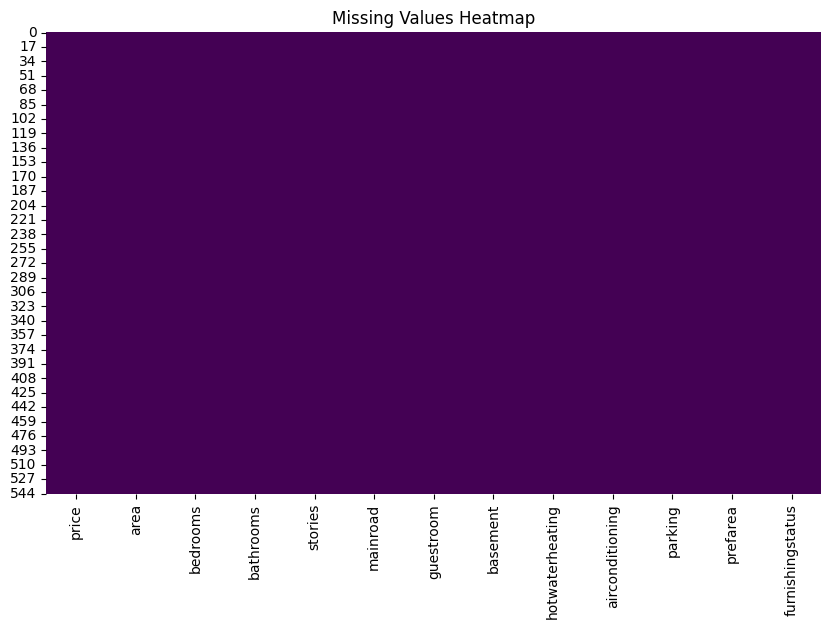

In [9]:
# Visualizing missing data using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [10]:
# Visualizing the distribution of numerical features
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()



<Figure size 1200x800 with 0 Axes>

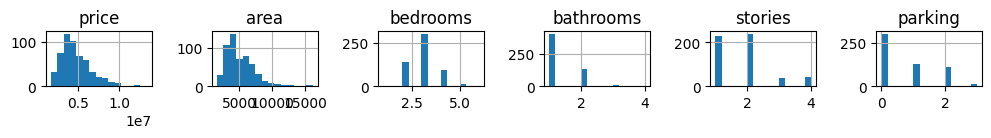

In [11]:
plt.figure(figsize=(12, 8))
df[numeric_columns].hist(bins=15, figsize=(15, 10), layout=(9, 9))
plt.tight_layout()
plt.show()

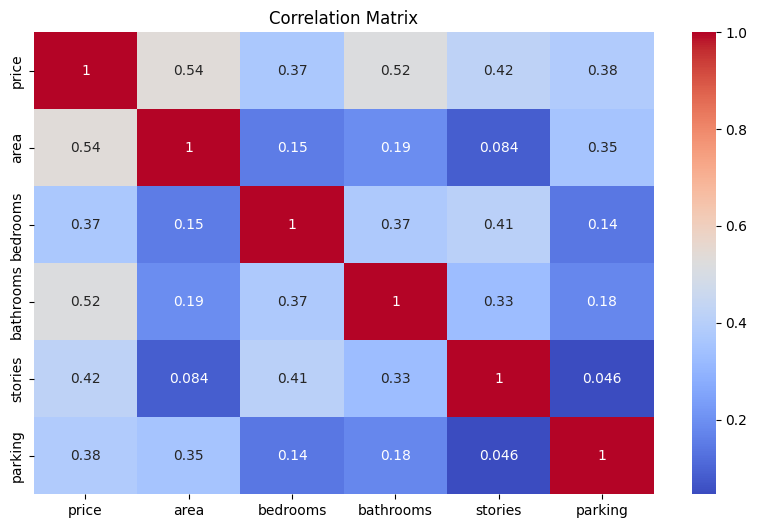

In [12]:
# Correlation matrix
plt.figure(figsize=(10, 6))
# Calculate the correlation matrix, excluding non-numeric columns
corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Skipped a pairplot fro numerical columns cuz it was optional(only for small datasets)


In [13]:
# Visualizing categorical features
categorical_columns = df.select_dtypes(include=[object]).columns.tolist()


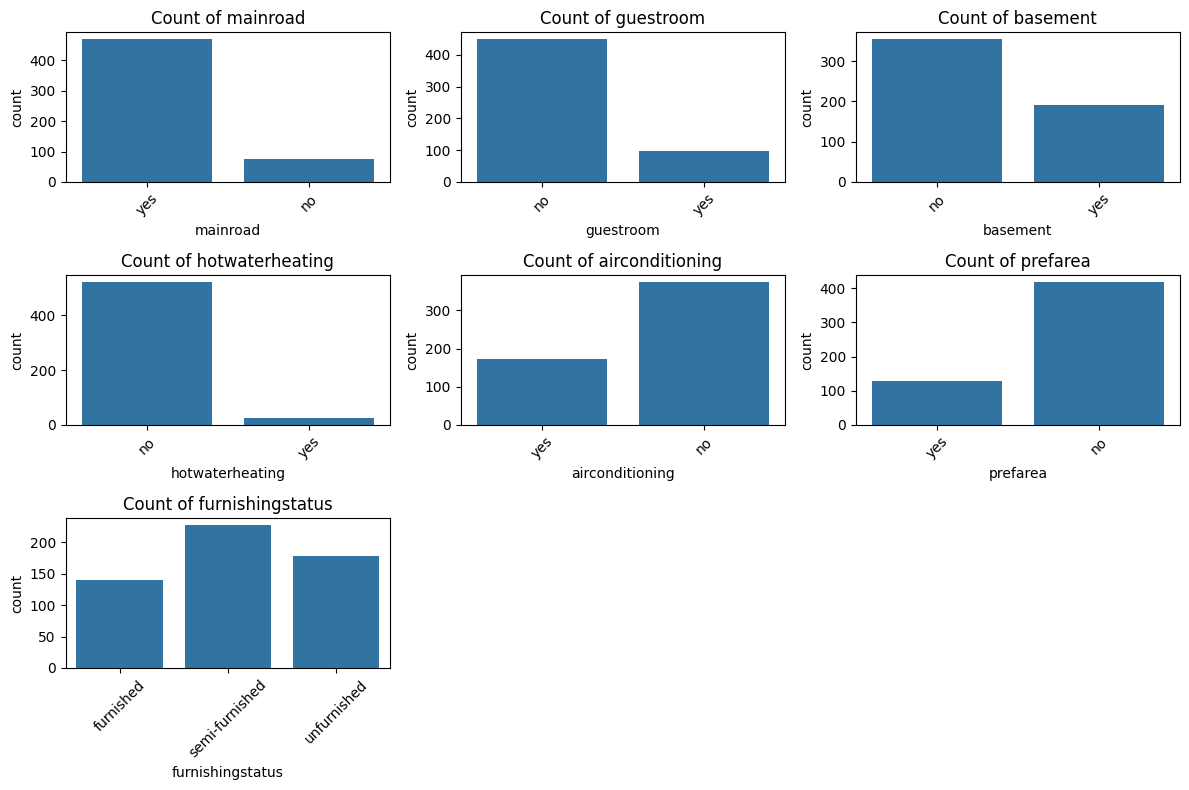

In [15]:
plt.figure(figsize=(12, 8))
# Calculate the number of rows and columns needed for subplots
num_cols = len(categorical_columns)
num_rows = (num_cols + 2) // 3  # Calculate rows, ensuring at least 2x3 grid

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(num_rows, 3, i) # Adjust subplot grid dynamically
    sns.countplot(data=df, x=col)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

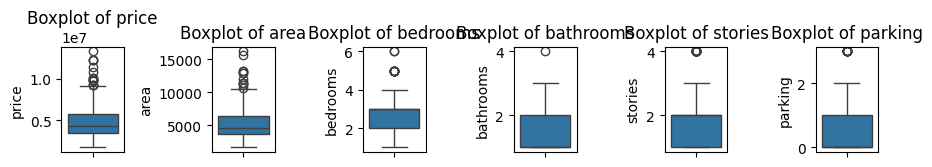

In [16]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_columns):
    plt.subplot(6, 8, i+1)
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [17]:
# Check unique values for categorical variables
print("\nUnique Values for Categorical Features:")
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")


Unique Values for Categorical Features:
mainroad: 2 unique values
guestroom: 2 unique values
basement: 2 unique values
hotwaterheating: 2 unique values
airconditioning: 2 unique values
prefarea: 2 unique values
furnishingstatus: 3 unique values


In [18]:
# Value counts for each categorical variable
print("\nValue Counts for Categorical Features:")
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


Value Counts for Categorical Features:

mainroad:
mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom:
guestroom
no     448
yes     97
Name: count, dtype: int64

basement:
basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating:
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning:
airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea:
prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus:
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64
